## Importing Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.style.use("default")
sns.set_theme()

## Load Dataset

In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Hey!\OneDrive\Desktop\Customer churn prediction & retention Platform\Risk_segmentation\outputs\customer_risk_segments.csv")
df

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Revenue_Per_Month,Customer_Value,Service_Count,Gender_Male,...,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Churn_Probability,Risk_Segment
0,2,53.85,108.15,1,86,3239,36.050000,107.7,3,True,...,False,False,False,False,True,False,False,True,0.945,High Risk
1,2,70.70,151.65,1,67,2701,50.550000,141.4,1,False,...,False,False,False,False,True,False,True,False,0.840,High Risk
2,8,99.65,820.50,1,86,5372,91.166667,797.2,5,False,...,False,True,False,False,True,False,True,False,0.950,High Risk
3,28,104.80,3046.05,1,84,5003,105.036207,2934.4,6,False,...,False,True,False,False,True,False,True,False,0.880,High Risk
4,49,103.70,5036.30,1,89,5340,100.726000,5081.3,6,True,...,False,True,False,False,True,False,False,False,0.895,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,45,5306,19.443836,1522.8,1,False,...,True,False,False,True,True,False,False,False,0.000,Low Risk
7039,24,84.80,1990.50,0,59,2140,79.620000,2035.2,7,True,...,False,True,True,False,True,False,False,True,0.030,Low Risk
7040,72,103.20,7362.90,0,71,5560,100.861644,7430.4,6,False,...,False,True,True,False,True,True,False,False,0.075,Low Risk
7041,11,29.60,346.45,0,59,2793,28.870833,325.6,1,False,...,False,False,False,False,True,False,True,False,0.025,Low Risk


## Dataset Check

In [6]:
print(df.info())
print(df["Risk_Segment"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Tenure Months                           7043 non-null   int64  
 1   Monthly Charges                         7043 non-null   float64
 2   Total Charges                           7043 non-null   float64
 3   Churn Value                             7043 non-null   int64  
 4   Churn Score                             7043 non-null   int64  
 5   CLTV                                    7043 non-null   int64  
 6   Revenue_Per_Month                       7043 non-null   float64
 7   Customer_Value                          7043 non-null   float64
 8   Service_Count                           7043 non-null   int64  
 9   Gender_Male                             7043 non-null   bool   
 10  Senior Citizen_Yes                      7043 non-null   bool

## Create Retention Recommendation Function

In [7]:
def retention_recommendation(row):

    # HIGH RISK RULES

    if row["Risk_Segment"] == "High Risk":

        if row["Monthly Charges"] > 80:
            return "Offer 15% Discount"

        elif row["Tenure Months"] < 12:
            return "Welcome Retention Package"

        elif row["Online Security_Yes"] == 0:
            return "Free Online Security"

        elif row["Tech Support_Yes"] == 0:
            return "Free Premium Support"

        elif row["Contract_One year"] == 0 and row["Contract_Two year"] == 0:
            return "Promote Long-Term Contract"

        else:
            return "Personal Retention Call"

    # MEDIUM RISK RULES

    elif row["Risk_Segment"] == "Medium Risk":

        if row["Monthly Charges"] > 80:
            return "5% Discount Offer"

        elif row["Online Security_Yes"] == 0:
            return "Security Upgrade Offer"

        else:
            return "Loyalty Reward Program"

    # LOW RISK RULES

    else:

        if row["CLTV"] > 5000:
            return "VIP Customer Benefits"

        else:
            return "Standard Customer Engagement"

## Generating Recommendation

In [8]:
df["Retention_Recommendation"] = df.apply(retention_recommendation,axis=1)

df[["Risk_Segment","Retention_Recommendation"]].head()

,Risk_Segment,Retention_Recommendation
0,High Risk,Welcome Retention Package
1,High Risk,Welcome Retention Package
2,High Risk,Offer 15% Discount
3,High Risk,Offer 15% Discount
4,High Risk,Offer 15% Discount


## Potential Revenue Saved

In [9]:
df["Potential_Revenue_Saved"] = (df["Monthly Charges"] * 12)

## View Results

In [10]:
df[["Risk_Segment","Monthly Charges","CLTV","Retention_Recommendation","Potential_Revenue_Saved"]].head()

,Risk_Segment,Monthly Charges,CLTV,Retention_Recommendation,Potential_Revenue_Saved
0,High Risk,53.85,3239,Welcome Retention Package,646.2
1,High Risk,70.70,2701,Welcome Retention Package,848.4
2,High Risk,99.65,5372,Offer 15% Discount,1195.8
3,High Risk,104.80,5003,Offer 15% Discount,1257.6
4,High Risk,103.70,5340,Offer 15% Discount,1244.4


## Save Main Recommendation File

In [13]:
df.to_csv("C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\retention_Intelligence\\outputs\\customer_retention_recommendations.csv",index=False)

print("Main Recommendation File Saved")

Main Recommendation File Saved


## High Risk Customer Action List

In [14]:
high_risk = df[df["Risk_Segment"] == "High Risk"]

high_risk.to_csv("C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\retention_Intelligence\\outputs\\high_risk_retention_actions.csv",index=False)

print("High Risk File Saved")

High Risk File Saved


## Retention Summary

In [15]:
summary = df.groupby("Retention_Recommendation").agg(
                        Customer_Count=("Risk_Segment","count"),
                        Avg_Churn_Probability=("Churn_Probability","mean"),
                        Avg_Monthly_Charges=("Monthly Charges","mean"),
                        Revenue_Saved=("Potential_Revenue_Saved","sum"))

summary = summary.reset_index()

summary

,Retention_Recommendation,Customer_Count,Avg_Churn_Probability,Avg_Monthly_Charges,Revenue_Saved
0,5% Discount Offer,140,0.699071,95.773571,160899.6
1,Free Online Security,135,0.900370,57.715556,93499.2
2,Free Premium Support,27,0.914630,64.764815,20983.8
3,Loyalty Reward Program,43,0.706628,58.934884,30410.4
4,Offer 15% Discount,770,0.930604,93.885844,867505.2
5,Personal Retention Call,5,0.891000,72.640000,4358.4
6,Promote Long-Term Contract,6,0.904167,64.508333,4644.6
7,Security Upgrade Offer,159,0.698522,49.871384,95154.6
8,Standard Customer Engagement,3143,0.046616,58.613777,2210677.2
9,VIP Customer Benefits,2030,0.036424,65.111552,1586117.4


## Save Summary

In [17]:
summary.to_csv("C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\retention_Intelligence\\outputs\\retention_summary.csv",index=False)

## Strategy Distribution

In [18]:
strategy_distribution = (df["Retention_Recommendation"].value_counts().reset_index())

strategy_distribution.columns = ["Strategy","Customer_Count"]

strategy_distribution

,Strategy,Customer_Count
0,Standard Customer Engagement,3143
1,VIP Customer Benefits,2030
2,Offer 15% Discount,770
3,Welcome Retention Package,585
4,Security Upgrade Offer,159
5,5% Discount Offer,140
6,Free Online Security,135
7,Loyalty Reward Program,43
8,Free Premium Support,27
9,Promote Long-Term Contract,6


## Save Distribution

In [19]:
strategy_distribution.to_csv("C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\retention_Intelligence\\outputs\\retention_strategy_distribution.csv",index=False)

## Revenue Saved Summary

In [20]:
revenue_saved = (df.groupby("Retention_Recommendation")["Potential_Revenue_Saved"].sum().reset_index())

revenue_saved

,Retention_Recommendation,Potential_Revenue_Saved
0,5% Discount Offer,160899.6
1,Free Online Security,93499.2
2,Free Premium Support,20983.8
3,Loyalty Reward Program,30410.4
4,Offer 15% Discount,867505.2
5,Personal Retention Call,4358.4
6,Promote Long-Term Contract,4644.6
7,Security Upgrade Offer,95154.6
8,Standard Customer Engagement,2210677.2
9,VIP Customer Benefits,1586117.4


## Save Revenue File

In [22]:
revenue_saved.to_csv("C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\retention_Intelligence\\outputs\\retention_revenue_saved.csv",index=False)

## KPI Dashboard

In [23]:
print("="*50)

print("TOTAL CUSTOMERS")
print(len(df))

print("="*50)

print("HIGH RISK CUSTOMERS")
print((df["Risk_Segment"]=="High Risk").sum())

print("="*50)

print("TOTAL POTENTIAL REVENUE SAVED")
print(
    round(df["Potential_Revenue_Saved"].sum(),2))

print("="*50)

print("AVERAGE CHURN PROBABILITY")
print(round(df["Churn_Probability"].mean(),4))

print("="*50)

print("MOST COMMON STRATEGY")
print(df["Retention_Recommendation"].mode()[0])

TOTAL CUSTOMERS
7043
HIGH RISK CUSTOMERS
1528
TOTAL POTENTIAL REVENUE SAVED
5473399.2
AVERAGE CHURN PROBABILITY
0.2664
MOST COMMON STRATEGY
Standard Customer Engagement


## Visualizations

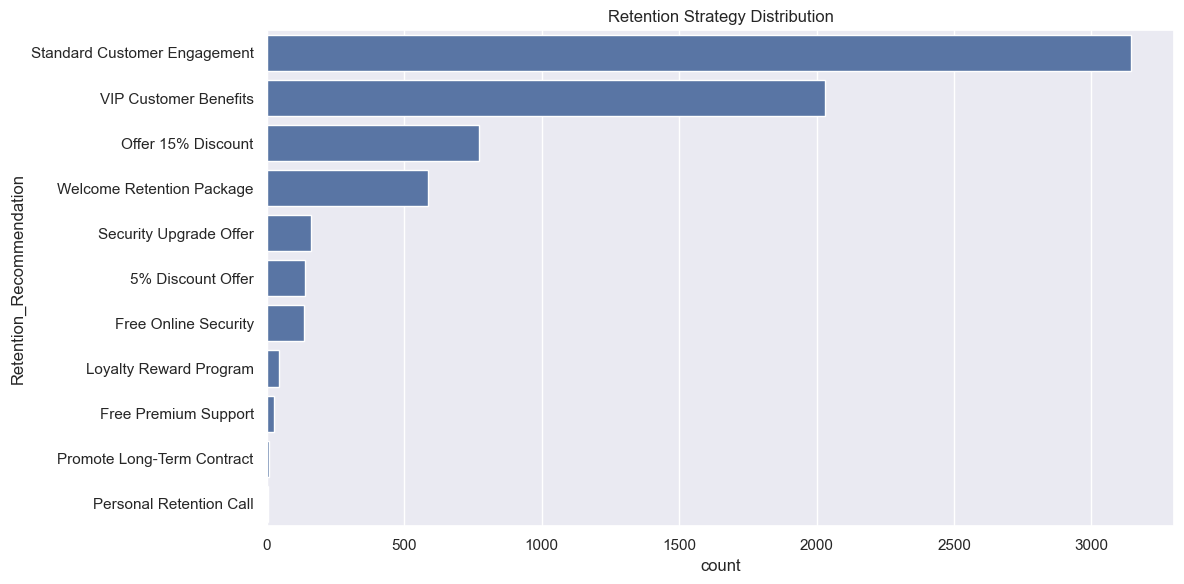

In [25]:
## Retention Strategy Distribution

plt.figure(figsize=(12,6))

sns.countplot(data=df,y="Retention_Recommendation",order=df["Retention_Recommendation"].value_counts().index)

plt.title("Retention Strategy Distribution")

plt.tight_layout()

plt.savefig("C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\retention_Intelligence\\visualizations\\retention_strategy_distribution.png")

plt.show()

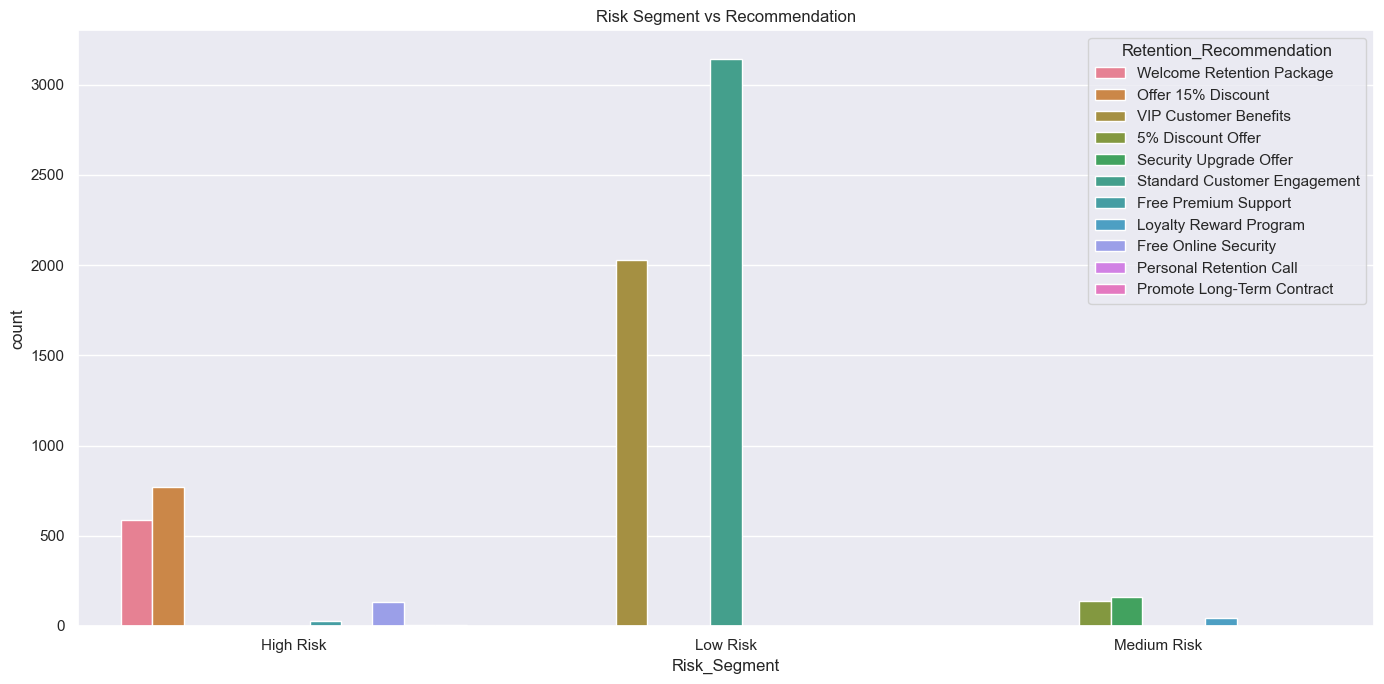

In [27]:
## Risk Segment vs Recommendation

plt.figure(figsize=(14,7))

sns.countplot(data=df,x="Risk_Segment",hue="Retention_Recommendation")

plt.title("Risk Segment vs Recommendation")

plt.tight_layout()

plt.savefig("C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\retention_Intelligence\\visualizations\\risk_vs_recommendation.png")

plt.show()

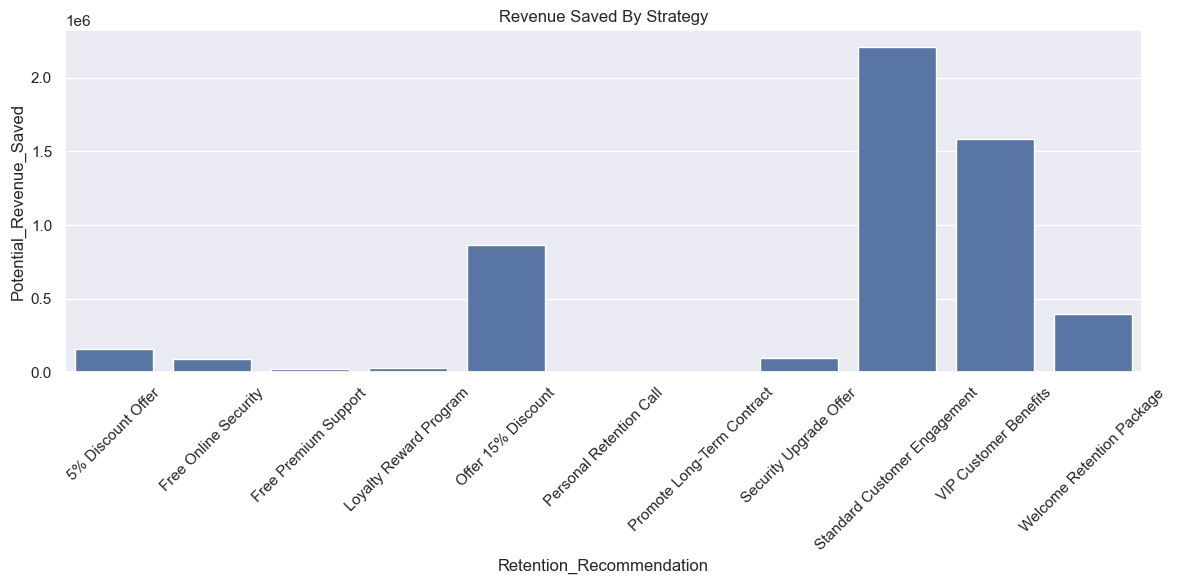

In [29]:
## Revenue Saved by Strategy
plt.figure(figsize=(12,6))

sns.barplot(data=revenue_saved,x="Retention_Recommendation",y="Potential_Revenue_Saved")

plt.xticks(rotation=45)

plt.title("Revenue Saved By Strategy")

plt.tight_layout()

plt.savefig("C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\retention_Intelligence\\visualizations\\revenue_saved_by_strategy.png")

plt.show()

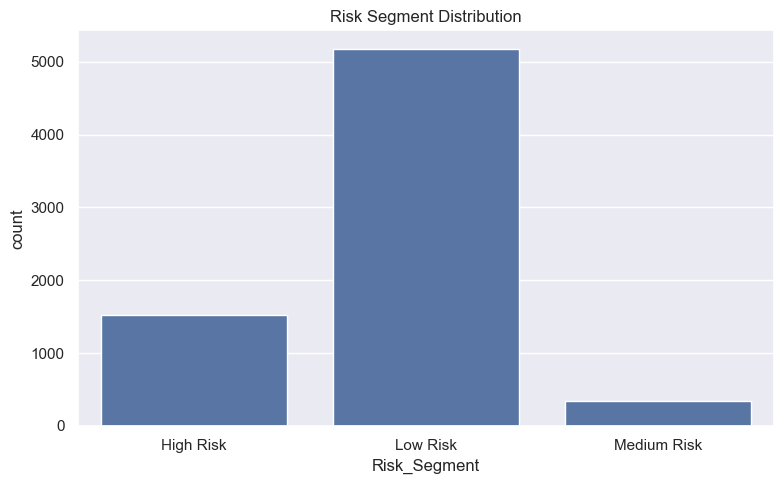

In [30]:
## Risk Segment Distribution

plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Risk_Segment")

plt.title("Risk Segment Distribution")

plt.tight_layout()

plt.savefig("C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\retention_Intelligence\\visualizations\\high_risk_customers.png")

plt.show()

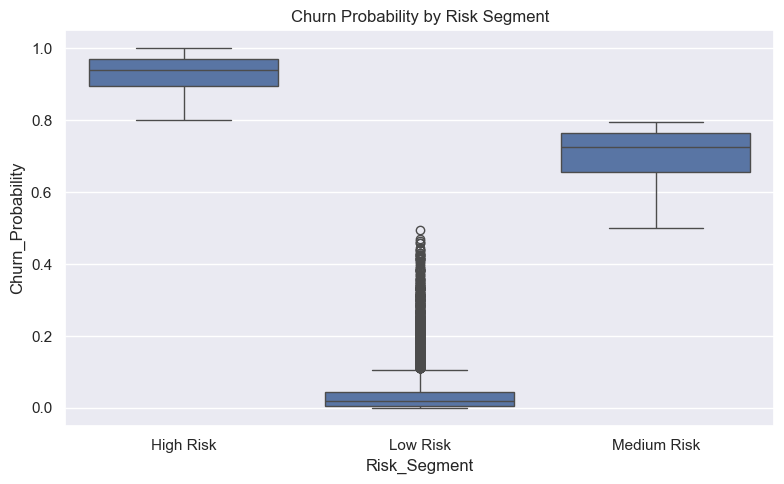

In [31]:
## Churn Probability by Risk Segment
plt.figure(figsize=(8,5))

sns.boxplot(data=df,x="Risk_Segment",y="Churn_Probability")

plt.title("Churn Probability by Risk Segment")

plt.tight_layout()

plt.savefig("C:\\Users\\Hey!\\OneDrive\\Desktop\\Customer churn prediction & retention Platform\\retention_Intelligence\\visualizations\\churn_probability_by_segment.png")

plt.show()